# BiLSTM-GRU

**Модель:** BiLSTM  GRU  mean pooling  FC + SpecAugment

In [7]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import time
from joblib import Parallel, delayed
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score as _f1
import matplotlib.pyplot as plt

exp_dir = Path().resolve()
sys.path.insert(0, str(exp_dir.parent.parent))
sys.path.insert(0, str(exp_dir))

from shared import config, data_utils, train_utils
from shared.evaluate import find_optimal_threshold, evaluate
from shared.results_utils import save_result_csv
from model import get_model

train_utils.set_seed(config.RANDOM_STATE)

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cpu


In [8]:
(
    paths_trainval, labels_trainval, letters_trainval,
    paths_test, labels_test, letters_test,
) = data_utils.get_test_split()

idx = np.arange(len(paths_trainval))
idx_tr, idx_val = train_test_split(
    idx, test_size=0.18, stratify=labels_trainval, random_state=config.RANDOM_STATE
)
paths_train,   paths_val   = paths_trainval[idx_tr],   paths_trainval[idx_val]
labels_train,  labels_val  = labels_trainval[idx_tr],  labels_trainval[idx_val]
letters_train, letters_val = letters_trainval[idx_tr], letters_trainval[idx_val]

In [9]:
N_MELS, N_FRAMES = config.N_MELS, 320

def load_mel(path):
    return data_utils.extract_mel_spectrogram(path, max_frames=N_FRAMES)

print("Mel...")
X_train = np.stack(Parallel(n_jobs=-1)(delayed(load_mel)(p) for p in paths_train))
X_val   = np.stack(Parallel(n_jobs=-1)(delayed(load_mel)(p) for p in paths_val))
X_test  = np.stack(Parallel(n_jobs=-1)(delayed(load_mel)(p) for p in paths_test))

mel_mean = X_train.mean(axis=(0, 2), keepdims=True)
mel_std  = np.where(X_train.std(axis=(0, 2), keepdims=True) < 1e-6, 1.0,
                    X_train.std(axis=(0, 2), keepdims=True))
X_train = (X_train - mel_mean) / mel_std
X_val   = (X_val   - mel_mean) / mel_std
X_test  = (X_test  - mel_mean) / mel_std
# (N, N_MELS, T)  (N, T, N_MELS) для LSTM
X_train = X_train.transpose(0, 2, 1)
X_val   = X_val.transpose(0, 2, 1)
X_test  = X_test.transpose(0, 2, 1)

Mel...


In [10]:
class MelSeqDataset(Dataset):
    def __init__(self, X, letters, labels, augment=False):
        self.X, self.letters, self.labels, self.augment = X, letters, labels, augment
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        x = self.X[i].copy()
        if self.augment:
            x = data_utils.augment_mel_spectrogram(x.T).T
        return torch.from_numpy(x).float(), torch.from_numpy(self.letters[i]).float(), int(self.labels[i])

BATCH = 32
train_loader = DataLoader(MelSeqDataset(X_train, letters_train, labels_train, augment=True),  batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(MelSeqDataset(X_val,   letters_val,   labels_val,   augment=False), batch_size=BATCH, shuffle=False)
test_loader  = DataLoader(MelSeqDataset(X_test,  letters_test,  labels_test,  augment=False), batch_size=BATCH, shuffle=False)

In [11]:
n_letters = letters_train.shape[1]
N_EPOCHS, LSTM_H, GRU_H, DROPOUT = 60, 128, 64, 0.3


model = get_model(input_size=N_MELS, num_classes=2, lstm_hidden=LSTM_H,
                  gru_hidden=GRU_H, n_letters=n_letters, dropout=DROPOUT).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())

weights = compute_class_weight("balanced", classes=np.unique(labels_train), y=labels_train)
criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32, device=DEVICE))
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = train_utils.get_lr_scheduler(optimizer)
early_stopping = train_utils.EarlyStopping(patience=config.EARLY_STOPPING_PATIENCE)
best_ckpt, best_f1 = exp_dir / "best_ckpt.pt", -1.0

def eval_loader(loader):
    model.eval()
    logits_list, true_list = [], []
    with torch.no_grad():
        for x, letters, y in loader:
            logits_list.append(model(x.to(DEVICE), letters.to(DEVICE)).cpu().numpy())
            true_list.extend(y.tolist())
    logits = np.concatenate(logits_list)
    proba  = torch.softmax(torch.from_numpy(logits), dim=1).numpy()[:, config.CLASS_BAD]
    return proba, np.array(true_list)

train_losses, val_f1s = [], []
t0 = time.perf_counter()

for epoch in range(N_EPOCHS):
    model.train()
    losses = []
    for x, letters, y in train_loader:
        x, letters, y = x.to(DEVICE), letters.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(x, letters), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), config.DEFAULT_GRAD_CLIP)
        optimizer.step()
        losses.append(loss.item())
    train_loss = np.mean(losses)
    train_losses.append(train_loss)

    val_proba, val_true = eval_loader(val_loader)
    thr = find_optimal_threshold(val_true, val_proba)
    val_f1 = _f1(val_true, (val_proba >= thr).astype(int),
                 pos_label=config.CLASS_BAD, average="binary")
    val_f1s.append(val_f1)

    if val_f1 > best_f1:
        best_f1 = val_f1
        train_utils.save_best_checkpoint(model, best_ckpt)
    scheduler.step(val_f1)
    print(f"Epoch {epoch+1}/{N_EPOCHS}  loss={train_loss:.4f}  val_f1_bad={val_f1:.4f}  thr={thr:.2f}")
    if early_stopping.step(val_f1):
        print(f"Early stopping на эпохе {epoch+1}")
        break

train_time_sec = time.perf_counter() - t0

Epoch 1/60  loss=0.6342  val_f1_bad=0.5723  thr=0.42
Epoch 2/60  loss=0.6026  val_f1_bad=0.6059  thr=0.50
Epoch 3/60  loss=0.5913  val_f1_bad=0.6104  thr=0.44
Epoch 4/60  loss=0.5875  val_f1_bad=0.6250  thr=0.41
Epoch 5/60  loss=0.5801  val_f1_bad=0.6218  thr=0.44
Epoch 6/60  loss=0.5795  val_f1_bad=0.6217  thr=0.32
Epoch 7/60  loss=0.5598  val_f1_bad=0.6335  thr=0.51
Epoch 8/60  loss=0.5700  val_f1_bad=0.6068  thr=0.49
Epoch 9/60  loss=0.5756  val_f1_bad=0.6250  thr=0.55
Epoch 10/60  loss=0.5619  val_f1_bad=0.6234  thr=0.36
Epoch 11/60  loss=0.5684  val_f1_bad=0.6291  thr=0.47
Epoch 12/60  loss=0.5580  val_f1_bad=0.6328  thr=0.44
Epoch 13/60  loss=0.5569  val_f1_bad=0.6372  thr=0.32
Epoch 14/60  loss=0.5527  val_f1_bad=0.6364  thr=0.34
Epoch 15/60  loss=0.5507  val_f1_bad=0.6332  thr=0.45
Epoch 16/60  loss=0.5650  val_f1_bad=0.6343  thr=0.46
Epoch 17/60  loss=0.5392  val_f1_bad=0.6329  thr=0.35
Epoch 18/60  loss=0.5431  val_f1_bad=0.6494  thr=0.28
Epoch 19/60  loss=0.5291  val_f1_bad=

              precision    recall  f1-score   support

        good       0.81      0.71      0.76       281
         bad       0.52      0.66      0.58       135

    accuracy                           0.69       416
   macro avg       0.67      0.69      0.67       416
weighted avg       0.72      0.69      0.70       416

Threshold : 0.39
Accuracy  : 0.6947
F1-macro  : 0.6713
F1-bad    : 0.5836
ROC-AUC   : 0.7519


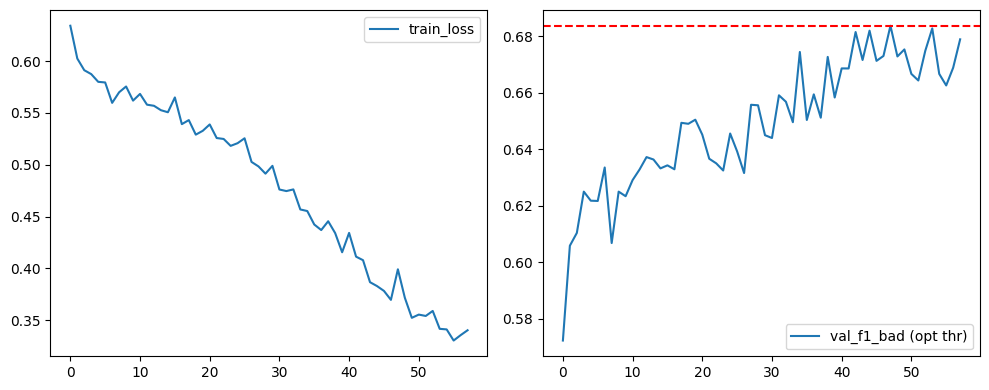

PosixPath('/Users/dk/Desktop/ВШЭ/ВКР/HSE_VKR_DetectingSpeechDefects/experiments/02_spectrogram_models/exp_bilstm_gru/result.csv')

In [12]:
train_utils.load_best_checkpoint(model, best_ckpt, DEVICE)


val_proba, val_true = eval_loader(val_loader)
optimal_threshold = find_optimal_threshold(val_true, val_proba)
test_proba, test_true = eval_loader(test_loader)
test_metrics = evaluate(test_true, test_proba, threshold=optimal_threshold, verbose=True)
pd.DataFrame({
    "path":    paths_test,
    "y_true":  test_true,
    "y_pred":  (test_proba >= optimal_threshold).astype(int),
    "y_proba": test_proba,
}).to_csv(exp_dir / "test_predictions.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(train_losses, label="train_loss"); axes[0].legend()
axes[1].plot(val_f1s, label="val_f1_bad (opt thr)")
axes[1].axhline(best_f1, color="r", linestyle="--"); axes[1].legend()
plt.tight_layout()
fig.savefig(exp_dir / "training_curves.png", dpi=120)
plt.show()

save_result_csv(
    exp_dir=exp_dir, experiment_id="exp_bilstm_gru",
    experiment_name="BiLSTM-GRU на log-mel + SpecAugment",
    accuracy=test_metrics["accuracy"], f1_macro=test_metrics["f1_macro"],
    f1_bad=test_metrics["f1_bad"],     roc_auc=test_metrics["roc_auc"],
    precision_bad=test_metrics["precision_bad"], recall_bad=test_metrics["recall_bad"],
    threshold=test_metrics["threshold"],
    embed_dim=64,
    embed_dim_note="BiLSTM(128)  GRU(64, unidirec.), mean pooling  fc=Linear(64+n_letters)",
    notes=f"SpecAugment + test | thr={optimal_threshold:.2f} | ckpt by val_f1_bad(opt_thr)",
    num_params=n_params, train_time_sec=train_time_sec,
)